# Image Classification

Use this notebook to complete the coding portion of the assignment. Once you have finished, you can submit your code by downloading the notebook as a .ipynb file (File > Download > Download .ipynb) and submitting that file on LMS.

In [1]:
# Type your student ID number as an integer here.
# e.g. STUDENT_ID = 22222222
STUDENT_ID = 21435050

Run the cell below to import modules that you are likely to need when completing the assignment.

In [2]:
import math

import cv2
import sklearn.svm
import sklearn.neighbors
import skimage.feature
import torchvision

import numpy as np
import matplotlib.pyplot as plt

The code in the cell below will download the CIFAR-10 dataset and create unique dataset for you based on your student ID. After running this cell you will have 3 important variables available to you for use in later tasks:

* `classes`: a list of three strings representing the three class names for your dataset.
* `dataset`: a list of `(img, lbl)` pairs representing examples from your dataset. Each `img` is a $32 \times 32 \times 3$ pixel image, and each `lbl` is an integer indicating the class of the image (0, 1, or 2). You can use `lbl` as an index into `classes` to get the class name as a string.

In [3]:
# Run this cell, but DO NOT MODIFY THE CODE INSIDE.

# Download CIFAR10.
cifar = torchvision.datasets.CIFAR10('./cifar10', download=True)
print()

# Create a unique dataset based on student ID.
rng = np.random.RandomState(seed=STUDENT_ID)
classes = rng.choice(cifar.classes, 3, replace=False).tolist()
print(f'Classes for student ID {STUDENT_ID}:')
print(classes)
dataset = []
for lbl, class_name in enumerate(classes):
    idx = cifar.class_to_idx[class_name]
    example_indices = np.where(np.asarray(cifar.targets) == idx)[0]
    for example_index in example_indices[:1000]:
        dataset.append((np.asarray(cifar[example_index][0]), lbl))
rng.shuffle(dataset)
del cifar

100%|██████████| 170498071/170498071 [00:01<00:00, 87925625.41it/s]


Extracting ./cifar10/cifar-10-python.tar.gz to ./cifar10

Classes for student ID 21435050:
['horse', 'deer', 'bird']


Run the cell below to preview the first 32 images from your dataset. This will give you an idea of the data that you are working with.

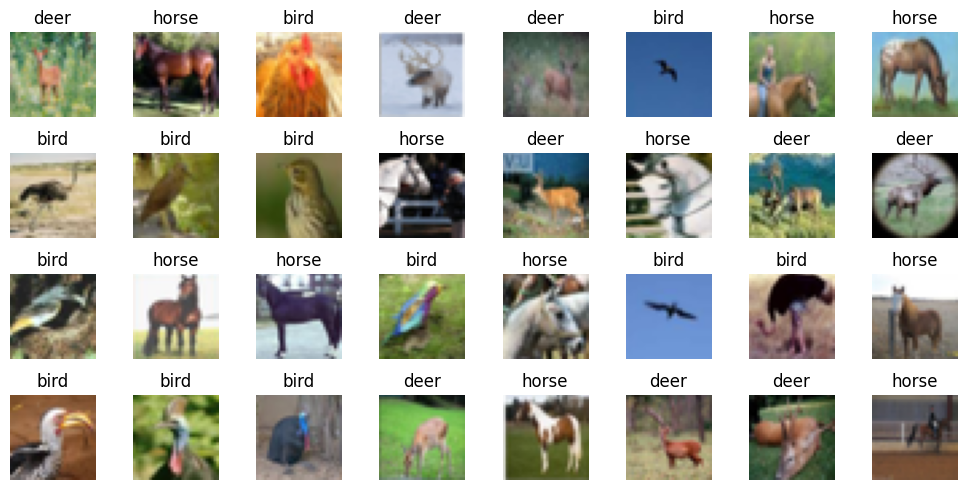

In [4]:
fig = plt.figure(figsize=(10, 5))
for i in range(32):
    img, lbl = dataset[i]

    # Each `lbl` is just an integer. To get the class name, we use the `classes`
    # list.
    img_class = classes[lbl]

    ax = plt.subplot(4, 8, i+1)
    ax.axis('off')
    ax.set_title(img_class)
    ax.imshow(img)
fig.tight_layout()

Now it's your turn to complete the remaining tasks of the assignment by adding code in code cells below. You will find Lab 02 to be a useful reference to have open while working.

_You can create additional code cells by clicking the "+ Code" button in the toolbar._

In [20]:
# Check dataset length and type
print(len(dataset))
print(type(dataset))

3000
<class 'list'>


# **2)**

In [6]:
# Due to dataset only have 3000 images, hence decide to choose the whole dataset to train, and the loop will have 3000 run times to extract labels from the first 3000 images.
N_IMGS = 3000
lbls = []
for i in range(N_IMGS):
    img, lbl = dataset[i]
    lbls.append(lbl)
lbls = np.array(lbls)

In [7]:
def classification_accuracy(predictions, lbls):
    return (predictions == lbls).sum()/len(predictions)

bad_predictions = np.zeros(N_IMGS)
acc = classification_accuracy(bad_predictions, lbls[:N_IMGS])
print(acc)

0.3333333333333333


In [8]:
green_means = []
blue_means = []
red_means = []
green_stds = []
blue_stds = []
red_stds = []
contrasts = []
dissimilarities = []
homogeneities = []
hogs = []

# Collect all features
for i in range(N_IMGS):
    img, lbl = dataset[i]
    img = np.array(img)

    # Colour moment features
    r, g, b = img.mean(axis=(0, 1))
    red_means.append(r)
    green_means.append(g)
    blue_means.append(b)
    r, g, b = img.std(axis=(0, 1))
    red_stds.append(r)
    green_stds.append(g)
    blue_stds.append(b)

    # GLCM features
    img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    cov = skimage.feature.graycomatrix(img_gray, distances=[1, 3, 5], angles=[0, math.pi/2, math.pi])
    contrasts.append(skimage.feature.graycoprops(cov, 'contrast'))
    dissimilarities.append(skimage.feature.graycoprops(cov, 'dissimilarity'))
    homogeneities.append(skimage.feature.graycoprops(cov, 'homogeneity'))

    # HOG features
    hog_f = skimage.feature.hog(img, channel_axis=2)
    hogs.append(hog_f)

# Normalising the features, and converting them all to numpy arrays for ease of use

def normalise(feature):
    feature = np.array(feature)
    return (feature-feature.min())/(feature.max()-feature.min())

green_means = normalise(green_means)
blue_means = normalise(blue_means)
red_means = normalise(red_means)
green_stds = normalise(green_stds)
blue_stds = normalise(blue_stds)
red_stds = normalise(red_stds)

contrasts = normalise(contrasts)
dissimilarities = normalise(dissimilarities)
homogeneities = normalise(homogeneities)

# HOG features are already normalised
hogs = np.array(hogs)

# For the following, there are many features created per image.
contrasts = contrasts.reshape([N_IMGS, -1]).transpose()
dissimilarities = dissimilarities.reshape([N_IMGS, -1]).transpose()
homogeneities = homogeneities.reshape([N_IMGS, -1]).transpose()
hogs = hogs.transpose()

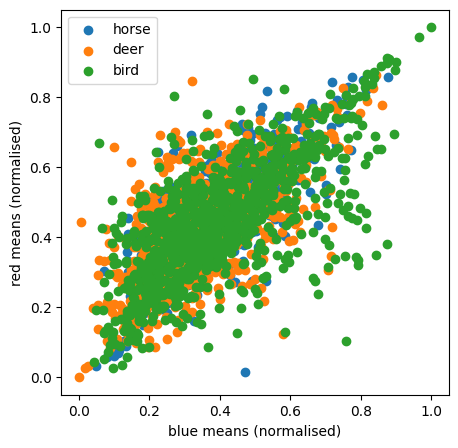

In [9]:
# Arbitrarily choose blue_means and red_means to represent our images for visualisation
plt.figure(figsize=(5, 5))
ax = plt.subplot(1, 1, 1)
for i in range(len(classes)):
    idx = (lbls == i)
    ax.scatter(blue_means[idx], red_means[idx], label=classes[i])
ax.legend()
ax.set_xlabel('blue means (normalised)')
_ = ax.set_ylabel('red means (normalised)')

**Adopting Graphically comparing discriminative power to improve the performance evaluation of different features.**

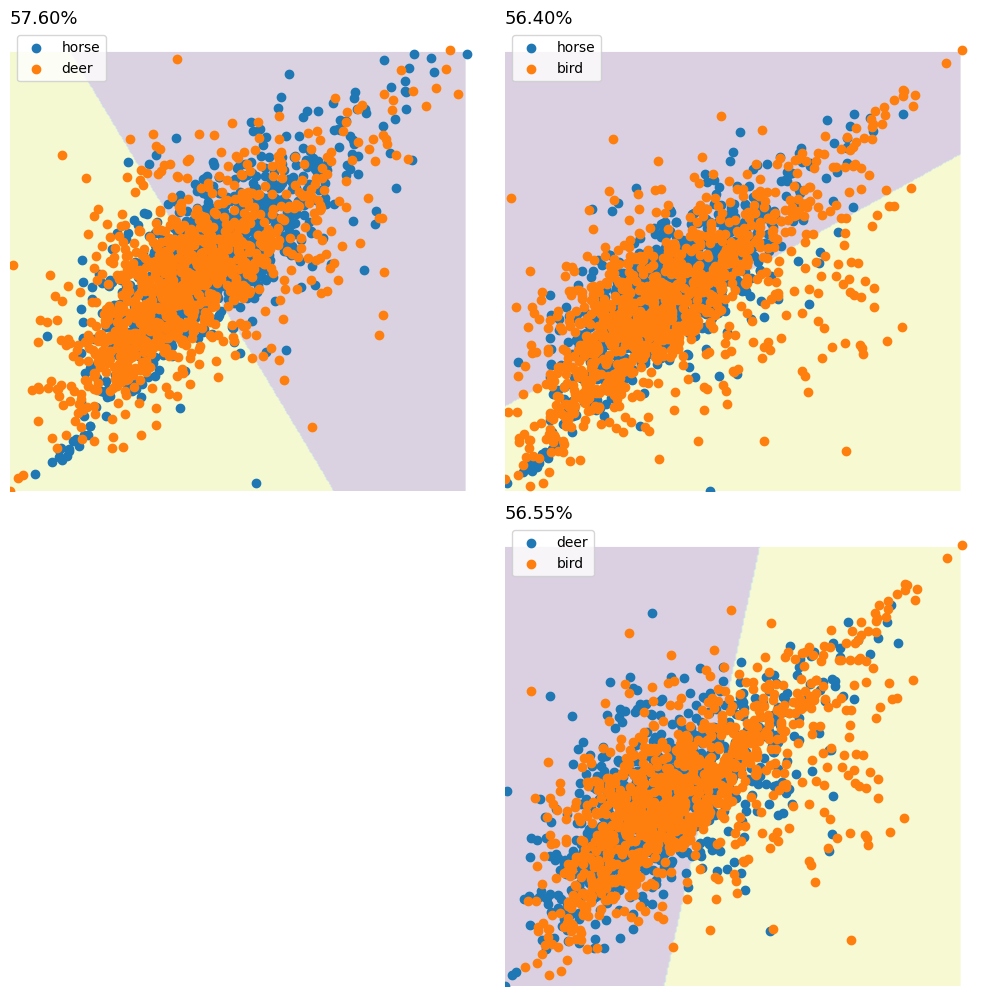

In [18]:
from sklearn import svm
from sklearn.metrics import accuracy_score

classes = ['horse', 'deer', 'bird']

def plot_decision_regions(x, y, svm, ax, border=0):
    '''
    Colours regions on ax by sampling a dense grid of the space
    and predicting a class with the provided svm.
    '''
    # Make a meshgrid that covers the whole space
    x_min, x_max = x.min() - border, x.max() + border
    y_min, y_max = y.min() - border, y.max() + border
    n = 300  # number of samples
    h_x = (x_max - x_min) / n
    h_y = (y_max - y_min) / n
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h_x), np.arange(y_min, y_max, h_y))

    # Make a prediction per spot in that space
    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the space as a surface with coloured regions
    ax.contourf(xx, yy, Z, alpha=0.2, antialiased=True)

def compare_discriminative_power(feature1, feature2, lbls, n=3):
    '''
    Plots an nxn grid of pairs of labels from the available classes,
    showing each image as a point in the 2D feature space, coloured by its label.
    '''
    features = np.stack([feature1, feature2], axis=-1)
    plt.figure(figsize=(5 * n, 5 * n))
    for lbl_1 in range(n):
        for lbl_2 in range(lbl_1 + 1, n):
            # Find index into features and lbls for this pair of labels
            idx1 = (lbls == lbl_1)
            idx2 = (lbls == lbl_2)
            idx = (idx1 | idx2)

            # Filtered labels for this pair
            filtered_lbls = lbls[idx]

            # Train an SVM for this pair of labels on these features
            svm_model = svm.SVC(kernel='linear')
            f_idx = features[idx]
            svm_model.fit(f_idx, filtered_lbls)

            # Plot
            ax = plt.subplot(n, n, lbl_1 * n + lbl_2 + 1)
            plot_decision_regions(f_idx[:, 0], f_idx[:, 1], svm_model, ax)
            ax.scatter(feature1[idx1], feature2[idx1], label=classes[lbl_1])
            ax.scatter(feature1[idx2], feature2[idx2], label=classes[lbl_2])
            ax.legend()
            ax.axis('off')

            # Show accuracy on plot
            pred = svm_model.predict(f_idx)
            accuracy = accuracy_score(filtered_lbls, pred)
            ax.text(ax.get_xlim()[0], ax.get_ylim()[1] * 1.01, f'{(accuracy * 100):5.2f}%', fontsize=13)

    plt.tight_layout()
    plt.show()

# Example usage with horse, deer, bird classes:
compare_discriminative_power(blue_means, red_means, lbls)


# **3)**

In [11]:
from sklearn.model_selection import train_test_split
features = np.stack([
    green_means,
    green_stds,
    blue_means,
    blue_stds,
    red_means,
    red_stds,
    *contrasts,
    *dissimilarities,
    *homogeneities,
    *hogs
], axis=-1)
print(features.shape)
print(lbls.shape)

# Split the data into training and testing sets with 80% training and 20% testing
# random_state=42 because the same train and test sets across different executions
X_train, X_test, Y_train, Y_test = train_test_split(features, lbls, test_size=0.2, random_state=42)

print("feature_training_set:" , len(X_train))
print("label_training_set:" , len(Y_train))

(3000, 357)
(3000,)
feature_training_set: 2400
label_training_set: 2400


# **4)**

**a)**

In [12]:
# Train an SVM and get predictions
svm = sklearn.svm.SVC()
svm.fit(X_train, Y_train)
preds_svm = svm.predict(X_test)

# Train a KNN and get predictions
knn = sklearn.neighbors.KNeighborsClassifier()
knn.fit(X_train, Y_train)
preds_knn = knn.predict(X_test)

In [13]:
#Check shape before finding Accuracy
print("Shape of preds_svm:", preds_svm.shape)
print("Shape of preds_knn:", preds_knn.shape)
print("Shape of Y_test:", Y_test.shape)

Shape of preds_svm: (600,)
Shape of preds_knn: (600,)
Shape of Y_test: (600,)


**b)**

Accuracy SVM: 76.50%
Accuracy KNN: 69.00%


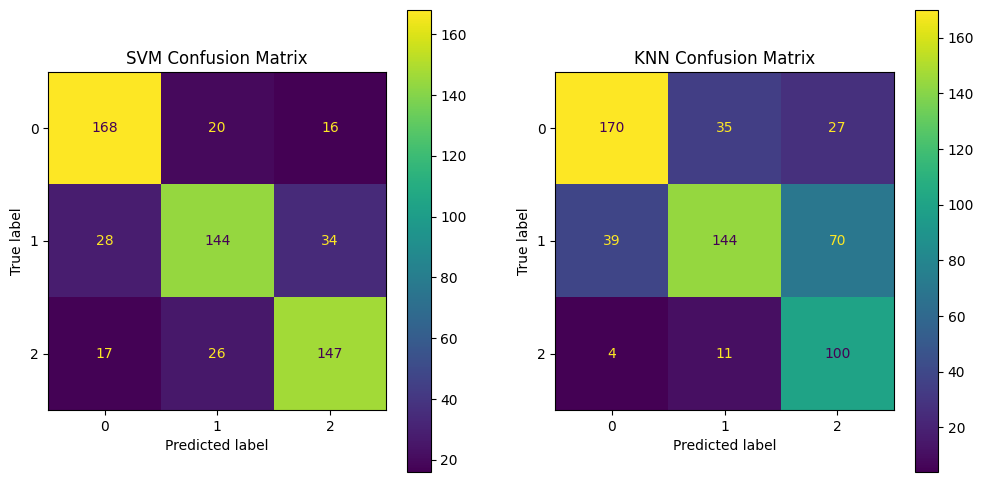

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
# Evaluate SVM with a confusion matrix and accuracy
ConfusionMatrixDisplay.from_predictions(preds_svm, Y_test, ax=ax[0])
ax[0].set_title('SVM Confusion Matrix')
acc_svm = classification_accuracy(preds_svm, Y_test)
print("Accuracy SVM:", f'{acc_svm*100:5.2f}%')

# Evaluate KNN with a confusion matrix and accuracy
ConfusionMatrixDisplay.from_predictions(preds_knn, Y_test, ax=ax[1])
ax[1].set_title('KNN Confusion Matrix')
acc_knn = classification_accuracy(preds_knn, Y_test)
print("Accuracy KNN:", f'{acc_knn*100:5.2f}%')

**c)**

In [15]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for SVM
param_svm = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto']
}

# Initialize the SVM model
svm = sklearn.svm.SVC()

# Initialize grid search CV for SVM
g_svm = GridSearchCV(svm, param_svm, cv=5, scoring='accuracy')
g_svm.fit(X_train, Y_train)

# Get the best parameters and accuracy
best_svm_params = g_svm.best_params_
best_svm_accuracy = g_svm.best_score_
print("Best SVM Parameters:", best_svm_params)
print("Best SVM Cross-Validated Accuracy:", f'{best_svm_accuracy*100:.2f}%')

Best SVM Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'poly'}
Best SVM Cross-Validated Accuracy: 73.21%


In [16]:
# Define the parameter grid for KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Initialize the KNN model
knn = sklearn.neighbors.KNeighborsClassifier()

# Initialize GridSearchCV for KNN
grid_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='accuracy')
grid_knn.fit(X_train, Y_train)

# Get the best parameters and accuracy
best_knn_params = grid_knn.best_params_
best_knn_accuracy = grid_knn.best_score_
print("Best KNN Parameters:", best_knn_params)
print("Best KNN Cross-Validated Accuracy:", f'{best_knn_accuracy*100:.2f}%')

Best KNN Parameters: {'metric': 'manhattan', 'n_neighbors': 9}
Best KNN Cross-Validated Accuracy: 70.08%
